In [8]:
import sys
sys.path.append("..")
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from src.process_images import load_pre_target

# Toggle this to save PNGs with an alpha channel (RGBA) or standard RGB.
SAVE_WITH_ALPHA = True

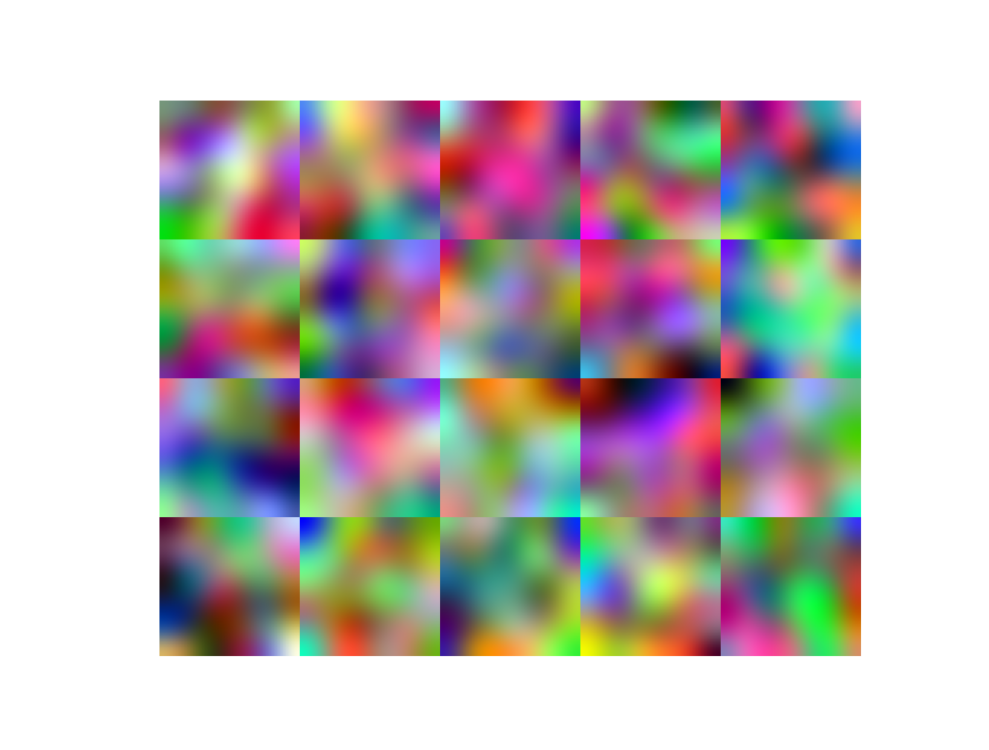

In [3]:


_, target = load_pre_target(
    pre_path="../data/siren-examples_best.png",
    target_path="../data/examples_best.png",
    rows=4, cols=5, top=60, bottom=55, left=98, right=78
)

def perlin_like(shape, scale=12, seed=0):
    rng = np.random.default_rng(seed)
    n = gaussian_filter(rng.random(shape[:2]), sigma=scale)
    return ((n - n.min()) / (n.max() - n.min()) * 255).astype(np.uint8)

ss = 11
noisy = np.stack([
    np.stack([perlin_like(target[k].shape, seed=k*3+c + ss) for c in range(3)], axis=-1)
    for k in range(len(target))
])

# Assemble into one grid image
th, tw = target[0].shape[:2]
grid = np.concatenate([
    np.concatenate([noisy[r*5+c] for c in range(5)], axis=1)
    for r in range(4)
], axis=0)

# Add white border matching the original crop amounts
border = (60, 55, 98, 78)  # top, bottom, left, right
h, w = grid.shape[:2]
canvas = np.full((h + border[0] + border[1], w + border[2] + border[3], 3), 255, dtype=np.uint8)
canvas[border[0]:border[0]+h, border[2]:border[2]+w] = grid

plt.figure(figsize=(10, 8))
plt.imshow(canvas)
plt.axis("off")
plt.tight_layout()
plt.show()

# Noise as individual images


Saved noise folders: ['noise01', 'noise02', 'noise03', 'noise04', 'noise05']
Saved with alpha: True
Loaded noise_sets: (5, 20, 91, 92, 3) uint8


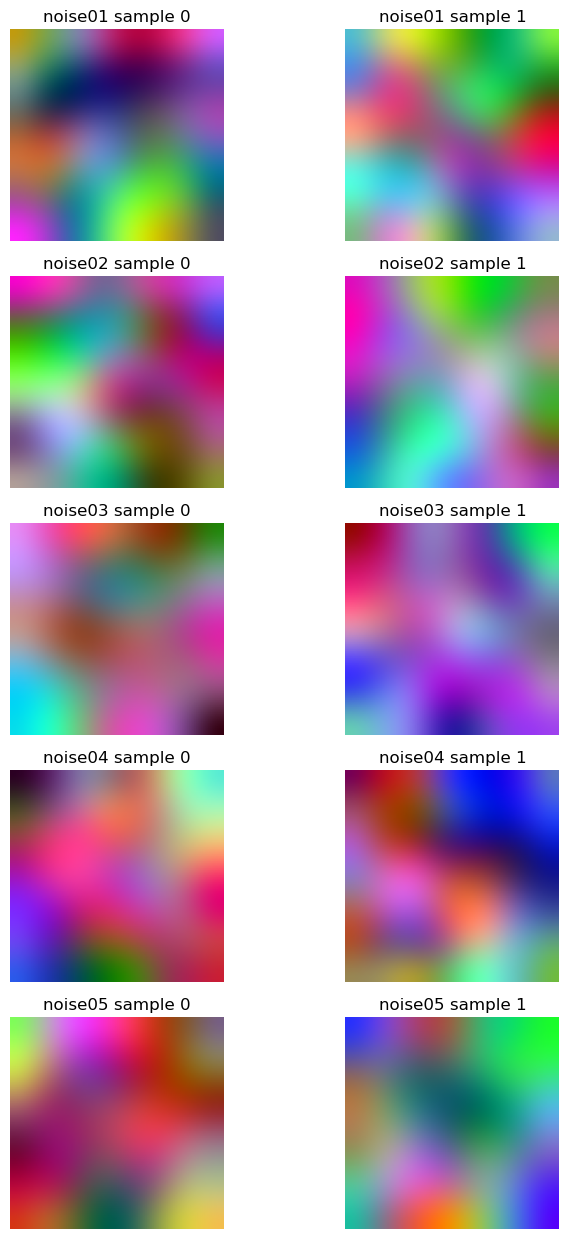

In [9]:
from pathlib import Path

from src.process_images import load_noise_sets_from_dir, save_image_set_to_dir

noise_root = (Path.cwd().parent / "data" / "noises")
noise_root.mkdir(parents=True, exist_ok=True)

n_noise_sets = 5
saved_sets = []
for seed in range(n_noise_sets):
    noise_dir = noise_root / f"noise{seed + 1:02d}"
    noisy_seed = np.stack([
        np.stack([perlin_like(target[k].shape, seed=seed * 100 + k * 3 + c) for c in range(3)], axis=-1)
        for k in range(len(target))
    ])

    if SAVE_WITH_ALPHA:
        alpha_seed = np.stack([
            perlin_like(target[k].shape, seed=50_000 + seed * 100 + k)
            for k in range(len(target))
        ])
        alpha = alpha_seed[..., None]
        noisy_seed = np.concatenate([noisy_seed, alpha], axis=-1)

    save_image_set_to_dir(noisy_seed, noise_dir, prefix="noise")
    saved_sets.append(noisy_seed)

noise_sets, noise_names = load_noise_sets_from_dir(noise_root)
print("Saved noise folders:", noise_names)
print("Saved with alpha:", SAVE_WITH_ALPHA)
print("Loaded noise_sets:", noise_sets.shape, noise_sets.dtype)

fig, axes = plt.subplots(len(noise_names), 2, figsize=(8, 2.5 * len(noise_names)))
if len(noise_names) == 1:
    axes = np.array([axes])

for row, name in enumerate(noise_names):
    axes[row, 0].imshow(noise_sets[row, 0])
    axes[row, 0].set_title(f"{name} sample 0")
    axes[row, 1].imshow(noise_sets[row, min(1, noise_sets.shape[1] - 1)])
    axes[row, 1].set_title(f"{name} sample 1")
    for ax in axes[row]:
        ax.axis("off")

plt.tight_layout()
plt.show()